In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
df = pd.read_csv('/content/drive/MyDrive/AIML_lab_sem4/exp 5,6,7/anomaly_detection_dataset_500_samples.csv')

In [3]:
df.head()

,Feature_1,Feature_2,Anomaly_Label
0,43.259073,53.716320,0
1,43.815246,43.397717,0
2,46.942411,42.966695,0
3,48.911594,55.493884,0
4,52.575238,69.263657,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Feature_1      500 non-null    float64
 1   Feature_2      500 non-null    float64
 2   Anomaly_Label  500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB


In [5]:
df['Anomaly_Label'].value_counts()

,count
Anomaly_Label,
0,470
1,30


In [6]:
X = df[['Feature_1', 'Feature_2']]

In [7]:
y_true = df['Anomaly_Label']

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
ISO = IsolationForest(contamination=0.06, random_state=42)
ISO_preds_raw = ISO.fit_predict(X_scaled)
ISO_preds = np.where(ISO_preds_raw == 1, 0, 1)

In [10]:
LOF = LocalOutlierFactor(contamination=0.06)
LOF_preds_raw = LOF.fit_predict(X_scaled)
LOF_preds = np.where(LOF_preds_raw == 1, 0, 1)

In [11]:
SVM = OneClassSVM(nu=0.06, kernel="rbf", gamma=0.1)
SVM_preds_raw = SVM.fit_predict(X_scaled)
SVM_preds = np.where(SVM_preds_raw == 1, 0, 1)

In [12]:
ISO_acc = accuracy_score(y_true, ISO_preds)
LOF_acc = accuracy_score(y_true, LOF_preds)
SVM_acc = accuracy_score(y_true, SVM_preds)

In [13]:
print("ISO Accuracy: ", ISO_acc)
print("LOF Accuracy: ", LOF_acc)
print("SVM Accuracy: ", SVM_acc)

ISO Accuracy:  0.964
LOF Accuracy:  0.88
SVM Accuracy:  0.93


In [14]:
ISO_p = precision_score(y_true, ISO_preds)
LOF_p = precision_score(y_true, LOF_preds)
SVM_p = precision_score(y_true, SVM_preds)

In [15]:
print("ISO Precision: ", ISO_p)
print("LOF Precision: ", LOF_p)
print("SVM Precision: ", SVM_p)

ISO Precision:  0.7
LOF Precision:  0.0
SVM Precision:  0.41935483870967744


In [16]:
ISO_r = recall_score(y_true, ISO_preds)
LOF_r = recall_score(y_true, LOF_preds)
SVM_r = recall_score(y_true, SVM_preds)

In [17]:
print("ISO Recall: ", ISO_r)
print("LOF Recall: ", LOF_r)
print("SVM Recall: ", SVM_r)

ISO Recall:  0.7
LOF Recall:  0.0
SVM Recall:  0.43333333333333335


In [18]:
ISO_f1 = f1_score(y_true, ISO_preds)
LOF_f1 = f1_score(y_true, LOF_preds)
SVM_f1 = f1_score(y_true, SVM_preds)

In [19]:
print("ISO F1: ", ISO_f1)
print("LOF F1: ", LOF_f1)
print("SVM F1: ", SVM_f1)

ISO F1:  0.7
LOF F1:  0.0
SVM F1:  0.4262295081967213


In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

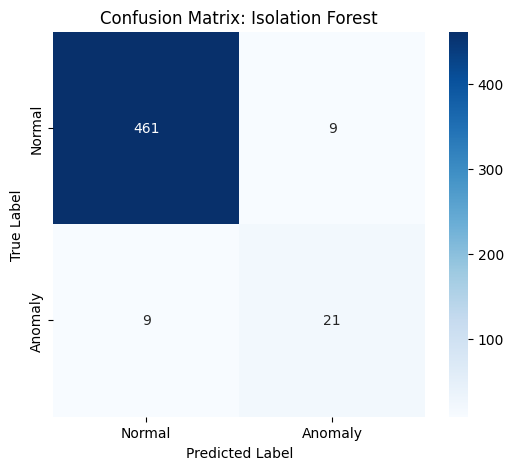

In [21]:
iso_cm = confusion_matrix(y_true, ISO_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(iso_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])

plt.title('Confusion Matrix: Isolation Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

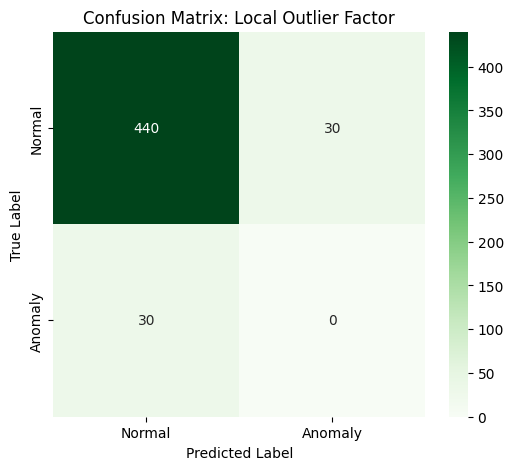

In [22]:
lof_cm = confusion_matrix(y_true, LOF_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(lof_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])

plt.title('Confusion Matrix: Local Outlier Factor')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

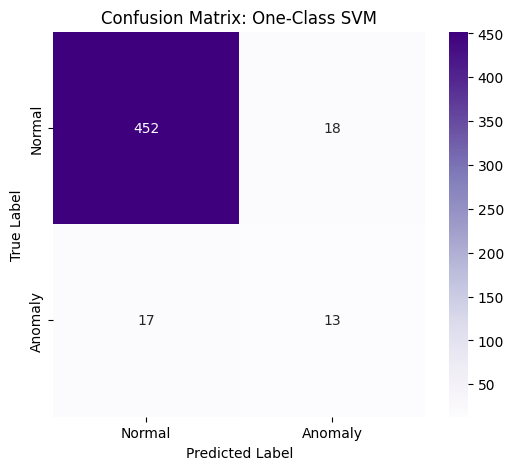

In [23]:
svm_cm = confusion_matrix(y_true, SVM_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])

plt.title('Confusion Matrix: One-Class SVM')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

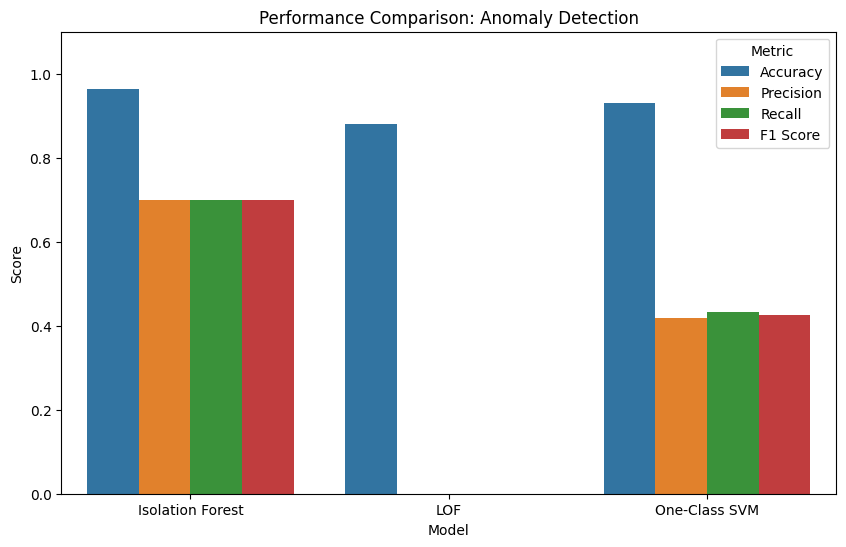

In [24]:
results_df = pd.DataFrame({
    'Model': ['Isolation Forest', 'LOF', 'One-Class SVM'],
    'Accuracy': [ISO_acc, LOF_acc, SVM_acc],
    'Precision': [ISO_p, LOF_p, SVM_p],
    'Recall': [ISO_r, LOF_r, SVM_r],
    'F1 Score': [ISO_f1, LOF_f1, SVM_f1]
})
df_plot = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=df_plot)
plt.title('Performance Comparison: Anomaly Detection')
plt.ylim(0, 1.1)
plt.show()

In [25]:
with open('/content/drive/MyDrive/AIML_lab_sem4/exp 5,6,7/Exp7_models/iso_forest.pkl', 'wb') as f:
    pickle.dump(ISO, f)

with open('/content/drive/MyDrive/AIML_lab_sem4/exp 5,6,7/Exp7_models/lof_model.pkl', 'wb') as f:
    pickle.dump(LOF, f)

with open('/content/drive/MyDrive/AIML_lab_sem4/exp 5,6,7/Exp7_models/oc_svm.pkl', 'wb') as f:
    pickle.dump(SVM, f)

with open('/content/drive/MyDrive/AIML_lab_sem4/exp 5,6,7/Exp7_models/anomaly_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("\nAll models and the scaler have been saved successfully.")


All models and the scaler have been saved successfully.
